## Train AI Model for Building Detection
- This task is called 'semantic segmentation' in AI context
- Use models from `segmentation-models-pytorch` library (https://smp.readthedocs.io)

### Setup & Import
GPU & GeoAI wrapper tool is require

In [1]:
# GPU is required - T4 GPU will be used
!nvidia-smi

Wed May  6 20:20:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   38C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# GeoAI = wrapper tool
%pip install 'geoai-py[all]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/1

In [3]:
import geoai
geoai.__version__

'0.37.2'

#### Data Download

In [4]:
train_raster_url = "https://github.com/emmpico26/Spatial-AI-Project/raw/refs/heads/main/train1.tif"
train_vector_url = "https://raw.githubusercontent.com/emmpico26/Spatial-AI-Project/refs/heads/main/export.geojson"

test_raster_url = "https://github.com/emmpico26/Spatial-AI-Project/raw/refs/heads/main/test.tif"


In [5]:
train_raster_path = geoai.download_file(train_raster_url)
train_vector_path = geoai.download_file(train_vector_url)

test_raster_path = geoai.download_file(test_raster_url)

### Visualization for training data

In [6]:
# function view_vector_interactive
geoai.view_vector_interactive(train_vector_path, tiles=train_raster_url) # param: (file path for label, raw data url)

In [ ]:
geoai.view_vector_interactive(train_vector_path, layer_name='Vector', tiles=test_raster_url, opacity=0.7)

### Create training data (image chips)

In [7]:
out_folder = "buildings"
tiles = geoai.export_geotiff_tiles(
    in_raster = train_raster_path, # satellite
    out_folder = out_folder, # folder containing image chips
    in_class_data = train_vector_path, # label
    tile_size = 512, # size of chips (width, height in px)
    stride = 256,
    buffer_radius = 0
)

Generated: 48, With features: 38: 100%|██████████| 48/48 [00:01<00:00, 34.43it/s]


### Model Training

In [ ]:
# function train_segmentation_model is required to train segmentation model
geoai.train_segmentation_model(
    images_dir = f"{out_folder}/images", # location for input image data
    labels_dir = f"{out_folder}/labels", # location for input label data
    output_dir = f"{out_folder}/unet_models", # location for storing trained model's spec/log
    architecture = "unet", # segmentation model
    encodder_name = "resnet34", # encoder model,
    encoder_weights = "imagenet",
    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    batch_size = 8,
    num_epochs = 20,
    learning_rate = 0.001,
    val_split = 0.2,
    verbose = True
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
# function train_segmentation_model is required to train segmentation model
geoai.train_segmentation_model(
    images_dir = f"{out_folder}/images", # location for input image data
    labels_dir = f"{out_folder}/labels", # location for input label data
    output_dir = f"{out_folder}/deeplabv3_models", # location for storing trained model's spec/log
    architecture = "deeplabv3", # segmentation model
    encodder_name = "resnet34", # encoder model,
    encoder_weights = "imagenet",
    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    batch_size = 8,
    num_epochs = 20,
    learning_rate = 0.001,
    val_split = 0.2,
    verbose = True
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [8]:
# function train_segmentation_model is required to train segmentation model
geoai.train_segmentation_model(
    images_dir = f"{out_folder}/images", # location for input image data
    labels_dir = f"{out_folder}/labels", # location for input label data
    output_dir = f"{out_folder}/segformer_models", # location for storing trained model's spec/log
    architecture = "segformer", # segmentation model
    encodder_name = "resnet34", # encoder model,
    encoder_weights = "imagenet",
    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    batch_size = 8,
    num_epochs = 20,
    learning_rate = 0.001,
    val_split = 0.2,
    verbose = True
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

### Inference (Prediction)

##### Unet

In [ ]:
masks_path = "naip_test_semantic_prediction.tif"
model_path = f"{out_folder}/unet_models/best_model.pth"

In [ ]:
#
geoai.semantic_segmentation(
    input_path = test_raster_path,
    output_path = masks_path,
    model_path = model_path,
    architecture = "unet", # segmentation model
    encodder_name = "resnet34", # encoder model,

    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    window_size = 512,
    stride = 256,
    batch_size = 4,
)

28it [00:00, 59.39it/s]


In [ ]:
# Visualize
geoai.view_raster(masks_path, basemap=test_raster_path, backend="ipyleaflet")

Map(center=[33.493109, -117.1434845], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…

##### DeepLabV3

In [ ]:
masks_path = "naip_test_semantic_prediction.tif"
model_path = f"{out_folder}/deeplabv3_models/best_model.pth"

In [ ]:
#
geoai.semantic_segmentation(
    input_path = test_raster_path,
    output_path = masks_path,
    model_path = model_path,
    architecture = "deeplabv3", # segmentation model
    encodder_name = "resnet34", # encoder model,

    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    window_size = 512,
    stride = 256,
    batch_size = 4,
)

28it [00:00, 52.73it/s]


In [ ]:
# Visualize
geoai.view_raster(masks_path, basemap=test_raster_path, backend='folium')

##### SegFormer

In [9]:
masks_path = "naip_test_semantic_prediction.tif"
model_path = f"{out_folder}/segformer_models/best_model.pth"

In [10]:
#
geoai.semantic_segmentation(
    input_path = test_raster_path,
    output_path = masks_path,
    model_path = model_path,
    architecture = "segformer", # segmentation model
    encodder_name = "resnet34", # encoder model,

    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    window_size = 512,
    stride = 256,
    batch_size = 4,
)

28it [00:00, 62.82it/s]


In [11]:
# Visualize
geoai.view_raster(masks_path, basemap=test_raster_path, backend="folium")

### Vectorize masks (output labels)

In [12]:
output_vector_path = "naip_test_semantic_prediction.geojson"
gdf = geoai.orthogonalize(masks_path, output_vector_path, epsilon=2) #smootyhes polygon o
gdf

Converting features: 100%|██████████| 77/77 [00:00<00:00, 104.00shape/s]


,geometry,value
0,"POLYGON ((486518.331 3706436.315, 486518.331 3...",1
1,"POLYGON ((486612.531 3706423.715, 486612.531 3...",1
2,"POLYGON ((486462.531 3706447.715, 486462.531 3...",1
3,"POLYGON ((486701.931 3706413.515, 486701.931 3...",1
4,"POLYGON ((486517.731 3706416.515, 486517.731 3...",1
...,...,...
69,"POLYGON ((486700.731 3705505.115, 486700.731 3...",1
70,"POLYGON ((486571.731 3705547.115, 486571.731 3...",1
71,"POLYGON ((486496.131 3705650.315, 486496.131 3...",1
72,"POLYGON ((486518.331 3705563.915, 486518.331 3...",1


### Performance Analysis

##### Unet

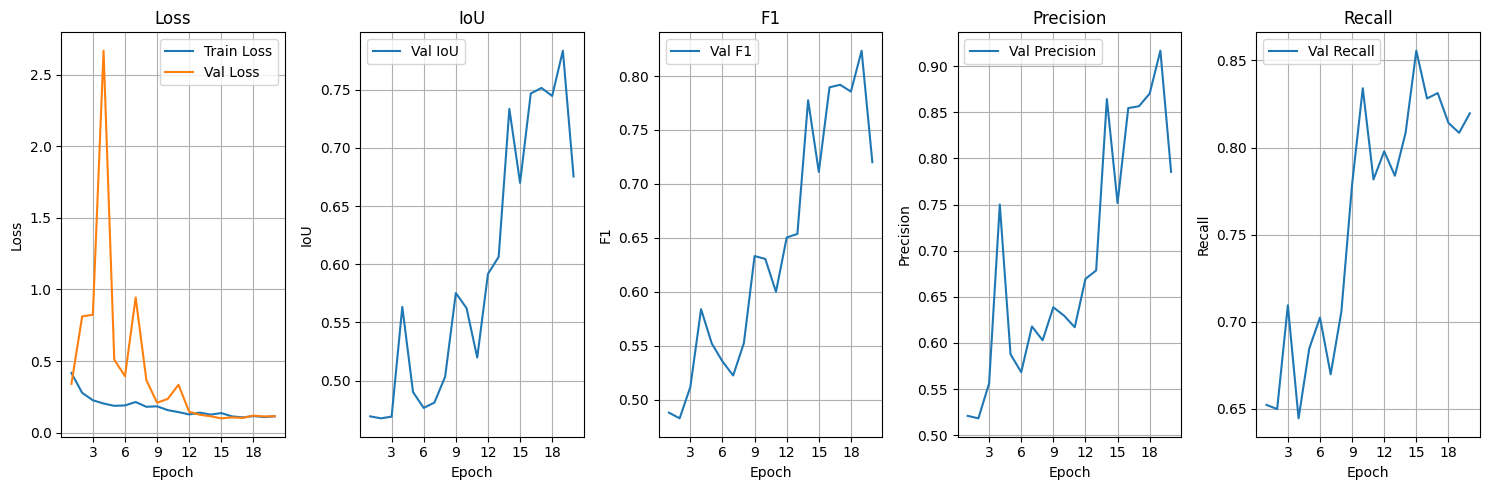

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.416282,0.340559,0.469205,0.487961,0.520972,0.652302
1,2,0.277832,0.811433,0.467503,0.482681,0.518273,0.649906
2,3,0.226012,0.823315,0.468977,0.511808,0.556128,0.709443
3,4,0.203121,2.667831,0.563397,0.583833,0.750037,0.644569
4,5,0.187067,0.509721,0.490120,0.552087,0.587737,0.684652
5,6,0.189770,0.393886,0.476439,0.535451,0.568338,0.702403
6,7,0.213712,0.944228,0.481078,0.522384,0.617877,0.669812
7,8,0.180256,0.366335,0.503271,0.552436,0.602927,0.705860
8,9,0.183581,0.208738,0.575271,0.633099,0.638673,0.778792
9,10,0.157013,0.235539,0.562316,0.630458,0.629615,0.834028


In [ ]:
geoai.plot_performance_metrics (
    history_path = f"{out_folder}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose = True
)

##### DeepLabV3

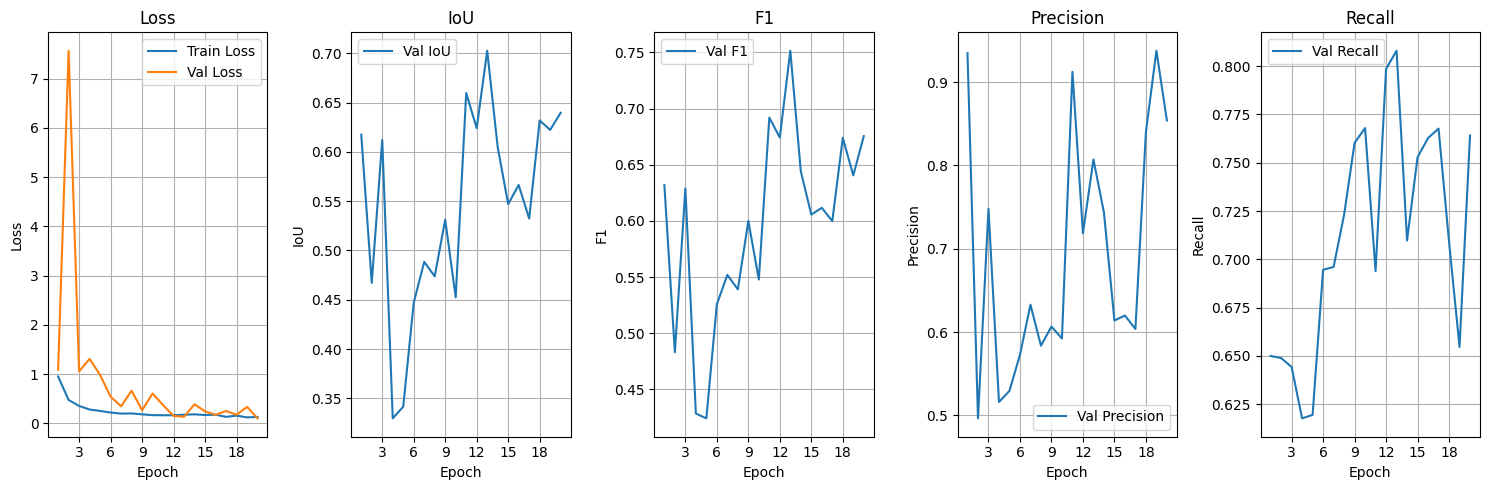

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.952917,1.088839,0.617380,0.631839,0.934760,0.650000
1,2,0.475924,7.565072,0.467108,0.482969,0.496466,0.648930
2,3,0.355117,1.056966,0.612114,0.628953,0.747922,0.644321
3,4,0.282368,1.310542,0.329734,0.428446,0.516061,0.617723
4,5,0.253800,0.982925,0.341549,0.424170,0.529473,0.619520
5,6,0.221664,0.541697,0.447007,0.525691,0.572746,0.694606
6,7,0.200017,0.348605,0.488382,0.551878,0.632856,0.696112
7,8,0.203078,0.664420,0.473788,0.539042,0.583674,0.723057
8,9,0.184768,0.268643,0.531166,0.599933,0.606606,0.760309
9,10,0.168011,0.608017,0.452414,0.547775,0.592288,0.767995


In [ ]:
geoai.plot_performance_metrics (
    history_path = f"{out_folder}/deeplabv3_models/training_history.pth",
    figsize=(15, 5),
    verbose = True
)

##### SegFormer

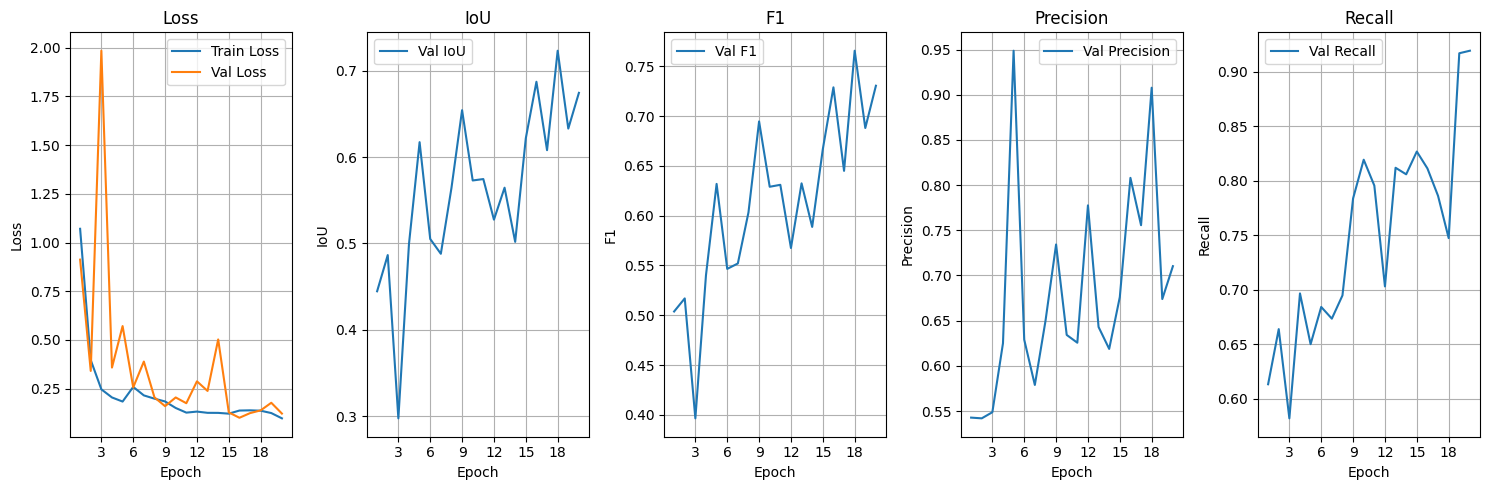

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,1.070662,0.912303,0.444587,0.503776,0.542705,0.613217
1,2,0.396730,0.340954,0.486559,0.516907,0.541907,0.663832
2,3,0.246392,1.984903,0.297369,0.396508,0.548673,0.581898
3,4,0.204745,0.358326,0.499433,0.540162,0.625003,0.696637
4,5,0.183689,0.571241,0.617391,0.631858,0.948682,0.650009
5,6,0.258909,0.256298,0.505215,0.546560,0.628959,0.684206
6,7,0.215333,0.389010,0.488044,0.551969,0.578837,0.673454
7,8,0.198533,0.205197,0.564326,0.603192,0.649546,0.694785
8,9,0.184109,0.159997,0.654436,0.694576,0.734286,0.783865
9,10,0.150727,0.204746,0.572997,0.628989,0.634204,0.819435


In [13]:
geoai.plot_performance_metrics (
    history_path = f"{out_folder}/segformer_models/training_history.pth",
    figsize=(15, 5),
    verbose = True
)